# 09 — Does it actually work? A detector-agnostic benchmark

Every notebook so far has measured the CAM on its own terms. Notebook 08 compared it to an FFT
receiver, but through **modelled** dwell counts — binomial sizing on one side, a $\chi^2$ model
on the other. The two engines were never handed the same data and never asked to produce an
answer.

This notebook does it the other way round. **Write the test first**, before any detector exists:
a harness that takes a detector as a black box, feeds it a sky, and scores what comes back. Then
plug in the CAM. Then plug in a floating-point FFT receiver. Same signal, same dwells, same
tolerance, same false-alarm budget.

**The signal is not ours.** It comes from [gps-sdr-sim](https://github.com/osqzss/gps-sdr-sim),
which builds the constellation from real broadcast ephemeris. Orbital Doppler, code Doppler,
path loss, navigation data bits and ionospheric delay are all there by construction rather than
by our approximation of them.

That change was forced. An earlier version of this notebook used a hand-written signal model
which advanced the carrier correctly but reused the same code phase for every dwell — so the
Doppler-induced code drift never accumulated. Section 6 shows the two side by side. The lesson
generalises: a model you wrote yourself will contain exactly the effects you thought of.

In [1]:
import os, csv, time, subprocess, pathlib
import numpy as np, matplotlib.pyplot as plt
from functools import lru_cache
from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import binom

FS, NS, CL, L1 = 2.046e6, 2046, 1023, 1575.42e6   # 2 samples/chip, 1 ms, 1023 chips
GRID  = np.arange(-20, 21) * 500.0                # +-10 kHz in 500 Hz bins
PRNS  = list(range(1, 33))
BLK   = int(0.1 * FS)                             # gps-sdr-sim updates state every 0.1 s
T_ALL = time.time()

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
TP   = ROOT / "third_party" / "gps-sdr-sim"
WORK = ROOT / "notebooks" / "_scen"                # generated data, gitignored
WORK.mkdir(parents=True, exist_ok=True)
print("third_party:", TP)

third_party: /home/user/acq-cam/third_party/gps-sdr-sim


---
## 1. The test requirement

### 1.1 What a detector is

The whole notebook hangs off one contract:

```
detector(dwells) -> set of (prn, code_phase_chips, doppler_hz)

    dwells : (M, 2*NS) complex, M consecutive 2 ms buffers, full precision
```

Full-precision samples go in, so **quantization is part of the detector under test**, not of the
harness. The CAM sign-quantizes on the way in; the FFT does not. That is the fair boundary — a
1-bit front end is a design choice a receiver makes, so it should be charged to the receiver
that makes it.

A detector returns a *set*: it is not told how many satellites are up, and it may declare as
many or as few as it likes. Everything it declares is scored.

### 1.2 The signal source

Build gps-sdr-sim from the vendored source. The only modification is `truth-dump.patch`, which
adds `fprintf` calls reporting the internal per-satellite state — PRN, carrier Doppler, code
frequency, code phase, gain — once per 0.1 s block. It touches nothing in the signal path and is
gated on an environment variable, so with `GPSSIM_TRUTH` unset the binary is upstream's.

The cell below verifies that claim rather than asserting it: same arguments, patched and
unpatched, and the I/Q must be **byte-identical**.

In [2]:
subprocess.run(f"cp {TP}/gpssim.c {TP}/gpssim_patched.c && "
               f"patch -p0 -s {TP}/gpssim_patched.c < {TP}/truth-dump.patch && "
               f"gcc {TP}/gpssim_patched.c -lm -O3 -I{TP} -o {TP}/gps-sdr-sim && "
               f"gcc {TP}/gpssim.c -lm -O3 -I{TP} -o {TP}/gps-sdr-sim-pristine",
               shell=True, check=True)

ARGS = ["-e", f"{TP}/brdc0010.22n", "-l", "35.68,139.77,10",
        "-t", "2022/01/01,00:00:00", "-d", "1", "-s", str(int(FS)), "-b", "16"]
env_off = {k: v for k, v in os.environ.items() if k != "GPSSIM_TRUTH"}
subprocess.run([f"{TP}/gps-sdr-sim-pristine", *ARGS, "-o", f"{WORK}/_a.bin"],
               check=True, env=env_off, capture_output=True)
subprocess.run([f"{TP}/gps-sdr-sim", *ARGS, "-o", f"{WORK}/_b.bin"],
               check=True, env=env_off, capture_output=True)
subprocess.run([f"{TP}/gps-sdr-sim", *ARGS, "-o", f"{WORK}/_c.bin"], check=True,
               env={**os.environ, "GPSSIM_TRUTH": f"{WORK}/_c.csv"}, capture_output=True)

a = open(f"{WORK}/_a.bin","rb").read(); b = open(f"{WORK}/_b.bin","rb").read()
c = open(f"{WORK}/_c.bin","rb").read()
print(f"patched vs pristine, no truth dump : {'IDENTICAL' if a==b else 'DIFFER'}")
print(f"patched vs pristine, truth dumping : {'IDENTICAL' if a==c else 'DIFFER'}")
print(f"\ntruth rows: {sum(1 for _ in open(f'{WORK}/_c.csv'))-1}")
print(open(f"{WORK}/_c.csv").read().split(chr(10))[0])
print(open(f"{WORK}/_c.csv").read().split(chr(10))[1])

patched vs pristine, no truth dump : IDENTICAL
patched vs pristine, truth dumping : IDENTICAL

truth rows: 99
block,gps_sec,prn,f_carr_hz,f_code_chips_s,code_phase_chip,gain
1,518400.100000,5,-2763.500464826,1022998.205519179,926.966211894,77


The patch is observation-only, proven not claimed.

Now generate the scenarios. Each is a different site and time of day, so the visible
constellation and its geometry differ between them. Generation is fast — under 0.1 s per second
of signal — so the cost is disk, not time.

In [3]:
SITES = [(35.68, 139.77, 10), (51.51, -0.13, 20), (-33.87, 151.21, 5), (40.71, -74.01, 15),
         (-23.55, -46.63, 760), (55.75, 37.62, 150), (1.35, 103.82, 5), (-34.60, -58.38, 25),
         (37.77, -122.42, 16), (28.61, 77.21, 216), (-1.29, 36.82, 1795), (64.13, -21.90, 40)]
HOURS   = [0, 3, 6, 9, 13, 17, 21]
N_SCEN  = 20

t0 = time.time()
SCEN = []
for i in range(N_SCEN):
    lat, lon, alt = SITES[i % len(SITES)]
    hh = HOURS[i % len(HOURS)]                       # 12 and 7 coprime -> 20 distinct combos
    binf, csvf = f"{WORK}/s{i:02d}.bin", f"{WORK}/s{i:02d}.csv"
    if not (os.path.exists(binf) and os.path.exists(csvf)):
        subprocess.run([f"{TP}/gps-sdr-sim", "-e", f"{TP}/brdc0010.22n",
                        "-l", f"{lat},{lon},{alt}", "-t", f"2022/01/01,{hh:02d}:00:00",
                        "-d", "1", "-s", str(int(FS)), "-b", "16", "-o", binf],
                       check=True, env={**os.environ, "GPSSIM_TRUTH": csvf},
                       capture_output=True)
    SCEN.append(dict(i=i, bin=binf, csv=csvf, site=(lat, lon, hh)))
print(f"{N_SCEN} scenarios in {time.time()-t0:.0f}s, "
      f"{sum(os.path.getsize(s['bin']) for s in SCEN)/1e6:.0f} MB")

20 scenarios in 0s, 147 MB


In [4]:
G2 = {1:(2,6),  2:(3,7),  3:(4,8),  4:(5,9),  5:(1,9),  6:(2,10), 7:(1,8),  8:(2,9),
      9:(3,10),10:(2,3), 11:(3,4), 12:(5,6), 13:(6,7), 14:(7,8), 15:(8,9), 16:(9,10),
      17:(1,4),18:(2,5), 19:(3,6), 20:(4,7), 21:(5,8), 22:(6,9), 23:(1,3), 24:(4,6),
      25:(5,7),26:(6,8), 27:(7,9), 28:(8,10),29:(1,6), 30:(2,7), 31:(3,8), 32:(4,9)}

@lru_cache(None)
def ca_code(prn):
    t1, t2 = G2[prn]
    g1 = np.ones(10, np.uint8); g2 = np.ones(10, np.uint8); o = np.empty(CL, np.uint8)
    for i in range(CL):
        o[i] = g1[9] ^ g2[t1-1] ^ g2[t2-1]
        f1 = g1[2] ^ g1[9]
        f2 = g2[1] ^ g2[2] ^ g2[5] ^ g2[7] ^ g2[8] ^ g2[9]
        g1[1:] = g1[:9]; g1[0] = f1; g2[1:] = g2[:9]; g2[0] = f2
    return 1.0 - 2.0 * o

def gss_replica(prn, fd, fcode, cp_g, n):
    '''Replica in gps-sdr-sim's own parameterisation: the code advances at fcode
    chips per second, which is where code Doppler lives.'''
    idx = cp_g + (fcode / FS) * np.arange(n)
    chips = ca_code(prn)[np.floor(idx).astype(np.int64) % CL]
    return chips * np.exp(1j*(2*np.pi*fd*np.arange(n)/FS))

def load_scenario(s):
    raw = np.fromfile(s["bin"], dtype=np.int16)
    x = raw[0::2].astype(np.float64) + 1j*raw[1::2].astype(np.float64)
    truth = {}
    for r in csv.DictReader(open(s["csv"])):
        truth.setdefault(int(r["block"]), []).append(
            dict(prn=int(r["prn"]), fd=float(r["f_carr_hz"]),
                 fcode=float(r["f_code_chips_s"]), cp_g=float(r["code_phase_chip"])))
    # per-satellite amplitude, median over 1 ms windows (a longer window can straddle a
    # 50 bps data-bit transition, which flips the sign mid-correlation and understates A)
    amp = {}
    for sat in truth[1]:
        v = [abs(np.vdot(gss_replica(sat["prn"], sat["fd"], sat["fcode"],
                                     (sat["cp_g"] + sat["fcode"]*w*NS/FS) % CL, NS),
                         x[w*NS:(w+1)*NS])) / NS for w in range(12)]
        amp[sat["prn"]] = float(np.median(v))
    return x, truth, amp

t0 = time.time()
for s in SCEN:
    s["x"], s["truth"], s["amp"] = load_scenario(s)
allp = sorted({p for s in SCEN for p in s["amp"]})
print(f"loaded in {time.time()-t0:.0f}s")
print(f"satellites per scenario: {min(len(s['amp']) for s in SCEN)}-{max(len(s['amp']) for s in SCEN)}")
print(f"distinct PRNs across all scenarios: {len(allp)} of 32 -> {allp}")

loaded in 3s
satellites per scenario: 9-16
distinct PRNs across all scenarios: 32 of 32 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


### 1.3 Turning a scenario into a sky at a chosen C/N0

gps-sdr-sim's output is essentially noiseless, with the *relative* power of each satellite set
by real path loss and antenna pattern. We supply the noise, which is what puts a C/N0 axis back
under our control:

$$\mathrm{C/N_0}_i = \frac{A_i^2}{2\sigma^2}\,f_s$$

where $A_i$ is the measured amplitude of satellite $i$ and $\sigma$ the noise per rail. Choosing
$\sigma$ slides the whole constellation up or down together; the ~10 dB **spread within** a sky
comes from geometry rather than from a uniform draw, so near-far is a property of the sky rather
than a modelling choice.

Ground truth per satellite comes from the dumped state, with code phase interpolated from the
0.1 s block boundary at the dumped `f_code` — which *is* the code drift the old model omitted.
Reported in the same convention the detectors use: a satellite at code phase $c$ is found at
$(1023 - c) \bmod 1023$, because the rows begin at chip 0.

In [5]:
M_DWELL   = 2 * NS                    # one dwell = 2 ms buffer
def sky_at(s, blk, w, sigma, n_dwells, rng):
    '''Extract n_dwells consecutive 2 ms dwells from scenario s, add noise, and return
    (dwells, sats) with sats in the same shape score_sky() expects.'''
    off  = (blk - 1) * BLK + w * n_dwells * M_DWELL
    seg  = s["x"][off:off + n_dwells*M_DWELL].reshape(n_dwells, M_DWELL).copy()
    seg += rng.normal(0, sigma, seg.shape) + 1j*rng.normal(0, sigma, seg.shape)
    dt   = (off - (blk-1)*BLK) / FS                       # seconds into the block
    sats = []
    for t in s["truth"][blk]:
        cp_g = (t["cp_g"] + t["fcode"]*dt) % CL           # <- code drift, from the generator
        sats.append(dict(prn=t["prn"], fd=t["fd"], cp=cp_g,
                         cn0=10*np.log10(s["amp"][t["prn"]]**2/(2*sigma**2)*FS)))
    return seg, sats

def sigma_for(s, cn0_strongest):
    '''Noise level placing the scenario's strongest satellite at a given C/N0.'''
    A = max(s["amp"].values())
    return np.sqrt(A**2 * FS / (2 * 10**(cn0_strongest/10)))

_s = SCEN[0]
_, _sats = sky_at(_s, 1, 0, sigma_for(_s, 48.0), 8, np.random.default_rng(0))
print(f"scenario 0 (lat {_s['site'][0]}, {_s['site'][2]:02d}:00) -> {len(_sats)} satellites")
for t in sorted(_sats, key=lambda t: -t["cn0"]):
    print(f"   PRN {t['prn']:2d}  {t['cn0']:5.1f} dB-Hz  fd {t['fd']:+8.1f} Hz  cp {t['cp']:7.2f} chips")

scenario 0 (lat 35.68, 00:00) -> 11 satellites
   PRN 24   48.0 dB-Hz  fd  +1527.7 Hz  cp  626.07 chips
   PRN 15   47.4 dB-Hz  fd   -645.9 Hz  cp  968.50 chips
   PRN 18   45.2 dB-Hz  fd   -955.6 Hz  cp  465.63 chips
   PRN  5   44.6 dB-Hz  fd  -2763.5 Hz  cp  926.97 chips
   PRN 23   44.4 dB-Hz  fd  +2742.7 Hz  cp  525.52 chips
   PRN 13   44.3 dB-Hz  fd  -2156.9 Hz  cp  579.13 chips
   PRN 28   41.7 dB-Hz  fd   -303.2 Hz  cp  366.92 chips
   PRN 14   40.2 dB-Hz  fd  -1212.1 Hz  cp  777.66 chips
   PRN 20   40.1 dB-Hz  fd  -3591.3 Hz  cp  682.47 chips
   PRN 12   39.0 dB-Hz  fd  +3439.9 Hz  cp  913.90 chips
   PRN 10   38.8 dB-Hz  fd  +3436.3 Hz  cp  837.94 chips


### 1.4 What counts as right

Every declared cell is classified against the satellites actually in the sky:

| class | test | harmful? |
|---|---|---|
| **hit** | a present satellite, same PRN, ≤ 1 chip, ≤ 500 Hz | no — this is the answer |
| **halo** | same PRN as a present satellite, ≤ 2 chips, ≤ 2 kHz, not a hit | no — the signal's own skirt spilling into neighbouring cells |
| **false alarm** | anything else | **yes** — a PRN that is not up there, or one that is, at an unrelated cell |

The **score for a sky is `hits / satellites_present`**. Halo cells are separated out rather than
counted as errors because a receiver hands the whole cluster to tracking and loses nothing.
Cross-correlation fires — a strong satellite lighting up a *different* PRN's row through the
65/1023 Gold bound — land in false alarms, which is right: those are ghosts a receiver chases.

In [6]:
HIT_CP,  HIT_FD  = 1.0, 500.0
HALO_CP, HALO_FD = 2.0, 2000.0

def true_cp(s):  return (CL - s["cp"]) % CL

def cp_error(declared_cp, s):
    e = abs(declared_cp - true_cp(s));  return min(e, CL - e)

def classify(dec, sats):
    prn, cp, fd = dec
    for s in sats:
        if s["prn"] == prn and cp_error(cp, s) <= HIT_CP and abs(fd - s["fd"]) <= HIT_FD:
            return "hit", s
    for s in sats:
        if s["prn"] == prn and cp_error(cp, s) <= HALO_CP and abs(fd - s["fd"]) <= HALO_FD:
            return "halo", s
    return "false", None

def score_sky(declared, sats):
    found, n_halo, n_false = set(), 0, 0
    for dec in declared:
        cls, s = classify(dec, sats)
        if   cls == "hit":  found.add(s["prn"])
        elif cls == "halo": n_halo += 1
        else:               n_false += 1
    return dict(score=len(found)/len(sats), found=found,
                n_sat=len(sats), n_halo=n_halo, n_false=n_false)

### 1.5 The harness

`evaluate` builds each sky **once** and hands identical dwells to every detector, so any
difference between them is the detector and not the draw.

In [7]:
CURRENT_SKY = [None]        # test hook for the reference detectors in 1.6 only

def trials_for(scen_list, windows, cn0_levels, n_dwells):
    '''The full trial list: (scenario, block, window, noise level).'''
    out = []
    for s in scen_list:
        per_blk = BLK // (n_dwells * M_DWELL)
        for w in range(min(windows, per_blk)):
            for c in cn0_levels:
                out.append((s, 1 + (w % 8), w, c))
    return out

def evaluate(detectors, trials, n_dwells, seed, progress=0):
    rng = np.random.default_rng(seed)
    res    = {n: [] for n in detectors}
    persat = {n: [] for n in detectors}
    t0 = time.time()
    for i, (s, blk, w, c) in enumerate(trials):
        dwells, sats = sky_at(s, blk, w, sigma_for(s, c), n_dwells, rng)
        CURRENT_SKY[0] = sats
        for name, det in detectors.items():
            sc = score_sky(det(dwells), sats)
            res[name].append(sc)
            for t in sats:
                persat[name].append((t["cn0"], t["prn"] in sc["found"]))
        if progress and (i+1) % progress == 0:
            print(f"   {i+1}/{len(trials)} trials  ({time.time()-t0:.0f}s)")
    return res, persat

def summarise(res):
    print(f"{'detector':>12} {'score':>8} {'halo/sky':>10} {'false/sky':>11}")
    for n, v in res.items():
        print(f"{n:>12} {np.mean([x['score'] for x in v]):>8.3f} "
              f"{np.mean([x['n_halo'] for x in v]):>10.2f} "
              f"{np.mean([x['n_false'] for x in v]):>11.3f}")

### 1.6 Validate the harness before trusting it

Three detectors with known answers. If these do not come out exactly as predicted, nothing later
in the notebook means anything.

- **oracle** — returns the truth. Must score 1.000 with zero false alarms.
- **null** — returns nothing. Must score 0.000 with zero false alarms.
- **shotgun** — declares 50,000 random cells, about 2% of the search space. It should find a real
  slice of every sky by luck alone, and be buried in false alarms doing it.

`shotgun` is the important one. It is why the score alone cannot be the whole story: a detector
that declares enough cells will find satellites by accident. Note what it costs — tens of
thousands of false alarms per sky, against the 0.01 both real detectors are held to below. What
closes the loophole is not the scoring rule but the **matched false-alarm budget** of §3 and §4.

In [8]:
def oracle(dwells):
    return {(s["prn"], true_cp(s), s["fd"]) for s in CURRENT_SKY[0]}

def null(dwells):
    return set()

_shot_rng = np.random.default_rng(5)
N_SHOT = 50_000
def shotgun(dwells):
    prn = _shot_rng.integers(1, 33, N_SHOT)
    cp  = _shot_rng.integers(0, 2*CL, N_SHOT) / 2.0
    fd  = _shot_rng.choice(GRID, N_SHOT)
    return set(zip(prn.tolist(), cp.tolist(), fd.tolist()))

_res, _ = evaluate(dict(oracle=oracle, null=null, shotgun=shotgun),
                   trials_for(SCEN[:3], 2, [46.0], 1), 1, seed=1)
summarise(_res)
_sh = _res["shotgun"]
print(f"\nshotgun cost: {np.mean([x['n_false'] for x in _sh]):,.0f} false alarms "
      f"per {np.mean([x['score'] for x in _sh]):.2f} of a sky found")

    detector    score   halo/sky   false/sky
      oracle    1.000       0.00       0.000
        null    0.000       0.00       0.000
     shotgun    0.136      11.17   49519.833

shotgun cost: 49,520 false alarms per 0.14 of a sky found


---
## 2. Training and test sets

The split is **by scenario**, not by window: the training scenarios are different sites at
different times, so a threshold tuned on them has to generalise to unseen geometry, not merely
to unseen noise.

In [9]:
TRAIN_SCEN, TEST_SCEN = SCEN[:6], SCEN[6:]
WINDOWS   = 4
CN0_SET   = [50.0, 45.0, 41.0]     # C/N0 of the strongest satellite; the rest follow geometry
MS        = [4, 8]
MMAX      = max(MS)
FA_BUDGET = 0.01                   # mean spurious declarations per sky, for BOTH detectors

TRIALS_TRAIN = trials_for(TRAIN_SCEN, 3, CN0_SET, MMAX)
TRIALS_TEST  = trials_for(TEST_SCEN, WINDOWS, CN0_SET, MMAX)
print(f"train: {len(TRAIN_SCEN)} scenarios -> {len(TRIALS_TRAIN)} trials")
print(f"test : {len(TEST_SCEN)} scenarios -> {len(TRIALS_TEST)} trials")
print(f"       ~{np.mean([len(s['amp']) for s in TEST_SCEN]):.1f} satellites each "
      f"-> ~{len(TRIALS_TEST)*np.mean([len(s['amp']) for s in TEST_SCEN]):.0f} satellite observations")

train: 6 scenarios -> 54 trials
test : 14 scenarios -> 168 trials
       ~12.4 satellites each -> ~2076 satellite observations


---
## 3. Detector A — the CAM

Same algorithm as notebook 00: one row per (satellite, Doppler) built at $\theta = 45°$,
sign-quantized keys slid over the 2 ms buffer, two rotations computed and the other two free by
complement, $\tau$ applied **inside** the readout so distances never escape, fire counts
accumulated over $M$ dwells.

In [10]:
def build_codebook(prns, grid):
    rows, tags = [], []
    for p in prns:
        code = ca_code(p)
        for f in grid:
            idx = (1.023e6/FS) * (1 + f/L1) * np.arange(NS)
            chips = code[np.floor(idx).astype(np.int64) % CL]
            x = chips * np.exp(1j*(2*np.pi*f*np.arange(NS)/FS + np.pi/4))
            rows.append(np.stack([x.real < 0, x.imag < 0], -1).ravel())
            tags.append((p, f))
    return np.array(rows), tags

ROWS, TAGS = build_codebook(PRNS, GRID)
RPM     = (1.0 - 2.0*ROWS).astype(np.float32)
TAG_PRN = np.array([t[0] for t in TAGS]);  TAG_FD = np.array([t[1] for t in TAGS])
W       = ROWS.shape[1]
HALF    = np.arange(NS)
CPS     = HALF / 2.0
NCELLS  = len(HALF) * ROWS.shape[0]
print(f"codebook : {ROWS.shape[0]} rows x {W} bits = {ROWS.size/1e6:.2f} Mbit")
print(f"search   : {len(HALF)} code phases x {ROWS.shape[0]} rows = {NCELLS:,} cells")

codebook : 1312 rows x 4092 bits = 5.37 Mbit
search   : 2046 code phases x 1312 rows = 2,684,352 cells


In [11]:
def fires(dwell, tau):
    '''The readout. Booleans out; the Hamming distance is local and never returned.'''
    b = np.stack([dwell.real < 0, dwell.imag < 0], -1)
    out = np.zeros((len(HALF), ROWS.shape[0]), bool)
    for q in (0, 1):                                    # q = 2, 3 come free by complement
        v = b if q == 0 else np.stack([~b[:, 1], b[:, 0]], -1)
        K = sliding_window_view(v.reshape(-1), W)[::2][:len(HALF)]
        d = (W - (1.0 - 2.0*K.astype(np.float32)) @ RPM.T) / 2      # local
        out |= (d <= tau)
        out |= (W - d <= tau)
    return out

def make_cam(tau, k, m):
    def cam(dwells):
        acc = np.zeros((len(HALF), ROWS.shape[0]), np.int16)
        for d in dwells[:m]:
            acc += fires(d, tau)
        fired = acc >= k
        return {(int(TAG_PRN[b]), CPS[a], float(TAG_FD[b])) for a, b in np.argwhere(fired)}
    return cam

### 3.1 Choosing $\tau$ and $k$ on the training set

Two knobs, and they are not the same kind of thing. **$\tau$ is a sense-amplifier setting** —
fixed when the array is designed. **$k$ is a counter threshold** — firmware. So we pick a single
$\tau$, admissible at *every* $M$, and let $k$ differ per $M$.

$p_0$ is measured against a **structured $H_0$**: cells in a real sky that belong to no
satellite. Not bare noise. `sim/gps/experiments.py` documents why — a clean wrong-cell key can
sit structurally closer to a row than noise ever does. The off-satellite mask uses exactly the
halo bounds, so "off-satellite in training" means precisely "would score as a false alarm".

In [12]:
TAUS = np.arange(1870, 1971, 10)

def region(s, cp_tol, fd_tol):
    e = np.minimum(np.abs(CPS - true_cp(s)), CL - np.abs(CPS - true_cp(s)))
    row = (TAG_PRN == s["prn"]) & (np.abs(TAG_FD - s["fd"]) <= fd_tol)
    return (e <= cp_tol)[:, None] & row[None, :]

def masks(sats):
    hit  = [region(s, HIT_CP, HIT_FD) for s in sats]
    halo = np.zeros((len(HALF), ROWS.shape[0]), bool)
    for s in sats:
        halo |= region(s, HALO_CP, HALO_FD)
    return hit, halo

def dwell_distance(dwell):
    '''CALIBRATION PROBE ONLY -- an oscilloscope on a node the receiver cannot read.
    Lets tau be swept without re-running the search; every decision still goes through fires().'''
    b = np.stack([dwell.real < 0, dwell.imag < 0], -1)
    best = np.full((len(HALF), ROWS.shape[0]), W, np.float32)
    for q in (0, 1):
        v = b if q == 0 else np.stack([~b[:, 1], b[:, 0]], -1)
        K = sliding_window_view(v.reshape(-1), W)[::2][:len(HALF)]
        d = (W - (1.0 - 2.0*K.astype(np.float32)) @ RPM.T) / 2
        np.minimum(best, d, out=best); np.minimum(best, W - d, out=best)
    return best

In [13]:
t0 = time.time()
rng = np.random.default_rng(1234)
off_hits = np.zeros(len(TAUS)); off_tot = 0
train_score = {m: np.zeros((len(TAUS), m)) for m in MS}

for (s, blk, w, c) in TRIALS_TRAIN:
    dwells, sats = sky_at(s, blk, w, sigma_for(s, c), MMAX, rng)
    hit, halo = masks(sats)
    Ds = [dwell_distance(d) for d in dwells]

    o = Ds[0][~halo]                                     # structured H0
    for j, t in enumerate(TAUS):
        off_hits[j] += (o <= t).sum()
    off_tot += o.size

    for j, t in enumerate(TAUS):
        acc = np.zeros((len(HALF), ROWS.shape[0]), np.int16)
        for i, D in enumerate(Ds):
            acc += (D <= t)
            if i+1 in MS:
                for k in range(1, i+2):
                    f = acc >= k
                    train_score[i+1][j, k-1] += sum(bool((f & h).any()) for h in hit)/len(hit)

p0 = off_hits / off_tot
train_score = {m: v/len(TRIALS_TRAIN) for m, v in train_score.items()}
print(f"training pass: {time.time()-t0:.0f}s over {len(TRIALS_TRAIN)} trials")
print(f"structured-H0 cells sampled: {off_tot:,}")

training pass: 128s over 54 trials
structured-H0 cells sampled: 144,915,840


In [14]:
rowsout = []
for j, t in enumerate(TAUS):
    for m in MS:
        for k in range(1, m+1):
            fa = binom.sf(k-1, m, p0[j]) * NCELLS if p0[j] > 0 else 0.0
            rowsout.append((int(t), m, k, p0[j], fa, train_score[m][j, k-1], fa <= FA_BUDGET))

def best_k(t, m):
    cand = [r for r in rowsout if r[0] == t and r[1] == m and r[6]]
    return max(cand, key=lambda r: r[5]) if cand else None

# One sense amplifier means one tau, so it must be admissible at EVERY M we run.
feasible = [t for t in TAUS.tolist() if all(best_k(t, m) for m in MS)]
best_tau = max(feasible, key=lambda t: np.mean([best_k(t, m)[5] for m in MS]))
CAMCFG = {m: best_k(best_tau, m)[2] for m in MS}

for m in MS:
    print(f"M = {m} dwells -- training score per (tau, k); 'x' = over the false-alarm budget")
    print(f"{'tau':>6} {'p0':>10} " + " ".join(f"{'k=%d'%k:>9}" for k in range(1, m+1)))
    for j, t in enumerate(TAUS):
        cells = []
        for k in range(1, m+1):
            fa = binom.sf(k-1, m, p0[j])*NCELLS if p0[j] > 0 else 0.0
            cells.append(f"{train_score[m][j,k-1]:>8.3f}{'' if fa <= FA_BUDGET else 'x'}")
        print(f"{t:>6} {p0[j]:>10.2e} " + " ".join(cells))
    print()
print(f"-> tau = {best_tau}, " + ", ".join(f"k(M={m}) = {CAMCFG[m]}" for m in MS))

M = 4 dwells -- training score per (tau, k); 'x' = over the false-alarm budget
   tau         p0       k=1       k=2       k=3       k=4
  1870   1.45e-07    0.218x    0.164    0.124    0.074
  1880   7.04e-07    0.264x    0.197    0.145    0.101
  1890   3.18e-06    0.314x    0.215    0.158    0.107
  1900   1.45e-05    0.368x    0.249    0.176    0.126
  1910   5.95e-05    0.449x    0.283x    0.207    0.157
  1920   2.19e-04    0.532x    0.346x    0.237    0.182
  1930   7.42e-04    0.627x    0.421x    0.288    0.207
  1940   2.29e-03    0.736x    0.497x    0.360x    0.255
  1950   6.47e-03    0.828x    0.582x    0.439x    0.304
  1960   1.67e-02    0.920x    0.675x    0.526x    0.357x
  1970   3.94e-02    0.967x    0.778x    0.626x    0.460x

M = 8 dwells -- training score per (tau, k); 'x' = over the false-alarm budget
   tau         p0       k=1       k=2       k=3       k=4       k=5       k=6       k=7       k=8
  1870   1.45e-07    0.282x    0.204    0.172    0.153    0.126    

---
## 4. Detector B — floating-point FFT

The conventional engine, in full precision. Per (PRN, Doppler): wipe the carrier, forward FFT,
multiply by the conjugate code spectrum, inverse FFT, take $|\cdot|^2$ — all 2046 code phases at
once — then accumulate non-coherently across dwells.

It uses the first 1 ms of each 2 ms buffer. The CAM needs the second millisecond only to slide
its window without a wrap seam, not for extra integration, so both integrate the same 1 ms per
dwell.

**Two decision rules, because the difference is itself a result.** The FFT produces a *ranked*
surface, so it has an option the CAM structurally does not:

- **`fft_peak`** — per PRN take the argmax and declare it if it clears the threshold. At most 32
  declarations. What a real acquisition engine does, and the honest strong baseline.
- **`fft_thr`** — declare every cell over threshold, no ranking. Matched to the CAM's constraint.

Thresholds come from the same training scenarios and the same budget: the per-cell $H_0$
distribution is estimated from PRNs that are genuinely *not* in the sky, its upper tail fitted
log-linearly, then extrapolated to each rule's number of declaration opportunities.

In [15]:
CODE_F = {}
for p in PRNS:
    idx = (1.023e6/FS) * np.arange(NS)
    CODE_F[p] = np.conj(np.fft.fft(ca_code(p)[np.floor(idx).astype(np.int64) % CL]))
WIPE = np.exp(-1j*2*np.pi*np.outer(GRID, np.arange(NS))/FS)

def fft_surfaces(dwells):
    '''Non-coherently accumulated |R|^2, normalised by its own median.

    The normalisation matters: the noise level differs between trials (that is how the
    C/N0 axis is swept), so an absolute threshold would not transfer. Dividing by the
    median of the surface -- a robust estimate of the noise floor, since almost every
    cell is noise -- makes the statistic dimensionless and the threshold portable.
    A real receiver does the same thing and calls it CFAR.'''
    acc = np.zeros((len(PRNS), len(GRID), NS))
    for d in dwells:
        Rw = np.fft.fft(d[:NS][None, :] * WIPE, axis=1)
        for i, p in enumerate(PRNS):
            acc[i] += np.abs(np.fft.ifft(Rw * CODE_F[p][None, :], axis=1))**2
    return acc / np.median(acc)

def make_fft(m, rule, thr_all, thr_peak):
    def det(dwells):
        S = fft_surfaces(dwells[:m])
        if rule == "peak":
            out = set()
            for i, p in enumerate(PRNS):
                j, a = np.unravel_index(np.argmax(S[i]), S[i].shape)
                if S[i, j, a] > thr_peak:
                    out.add((p, a/2.0, float(GRID[j])))
            return out
        return {(PRNS[i], a/2.0, float(GRID[j])) for i, j, a in np.argwhere(S > thr_all)}
    return det

In [16]:
t0 = time.time()
rng = np.random.default_rng(4321)
fft_h0 = {m: [] for m in MS}
for (s_, blk, w, c) in TRIALS_TRAIN:
    dwells, sats = sky_at(s_, blk, w, sigma_for(s_, c), MMAX, rng)
    present = {t["prn"] for t in sats}
    for m in MS:
        # Call the SAME function the detector calls. Accumulating individually
        # normalised surfaces and normalising the accumulation are different
        # statistics -- they differ by roughly a factor of M -- so the training
        # statistic has to be produced exactly as the detector produces it.
        S = fft_surfaces(dwells[:m])
        for pi, p in enumerate(PRNS):
            if p not in present:
                fft_h0[m].append(S[pi].ravel()[::101].copy())
fft_h0 = {m: np.concatenate(v) for m, v in fft_h0.items()}
print(f"H0 collected in {time.time()-t0:.0f}s")

H0 collected in 34s


Under $H_0$ the accumulated statistic is $\chi^2_{2M}$, and dividing by the surface median
turns it into $\chi^2_{2M}/\mathrm{median}(\chi^2_{2M})$. Check that against the measured
$H_0$ before using it: if the model holds, the threshold can be read off the distribution exactly
rather than extrapolated from a fit that runs past the end of the data.

In [17]:
from scipy.stats import chi2
print(f"{'M':>3} {'quantile':>10} {'measured':>10} {'chi2 model':>12}")
for m in MS:
    h0, med = fft_h0[m], chi2.median(2*m)
    for q in (0.9, 0.99, 0.999, 0.9999):
        print(f"{m:>3} {q:>10} {np.quantile(h0, q):>10.2f} {chi2.ppf(q, 2*m)/med:>12.2f}")
    print(f"{'':>3} {'max':>10} {h0.max():>10.2f} {'':>12}")

  M   quantile   measured   chi2 model
  4        0.9       1.83         1.82
  4       0.99       2.76         2.74
  4      0.999       3.60         3.56
  4     0.9999       4.41         4.33
           max       6.27             
  8        0.9       1.54         1.53
  8       0.99       2.12         2.09
  8      0.999       2.62         2.56
  8     0.9999       3.09         2.99
           max       4.27             


In [18]:
# Thresholds from the validated chi2 model. fft_thr protects every cell; fft_peak only
# needs to protect the per-PRN maximum for the ~20 PRNs that are not up there.
N_ABSENT = 20
FFTCFG = {}
for m in MS:
    med = chi2.median(2*m)
    thr_all  = chi2.isf(FA_BUDGET / NCELLS, 2*m) / med
    thr_peak = chi2.isf(FA_BUDGET / (N_ABSENT * len(GRID) * NS), 2*m) / med
    FFTCFG[m] = (thr_all, thr_peak)
    exc = (fft_h0[m] > thr_all).mean()
    print(f"M={m}: thr(fft_thr) {thr_all:>6.2f}   thr(fft_peak) {thr_peak:>6.2f}  "
          f"({100*(1-thr_peak/thr_all):.1f}% lower)   measured exceedance {exc:.1e} "
          f"(target {FA_BUDGET/NCELLS:.1e})")

M=4: thr(fft_thr)   7.54   thr(fft_peak)   7.40  (1.9% lower)   measured exceedance 0.0e+00 (target 3.7e-09)
M=8: thr(fft_thr)   4.72   thr(fft_peak)   4.65  (1.6% lower)   measured exceedance 0.0e+00 (target 3.7e-09)


The two thresholds land within about a percent of each other. Because the null tail falls
steeply, protecting 2.7 million cells costs barely more threshold than protecting twenty.
**Ranking buys almost nothing here** — so the CAM's inability to rank is not, on this evidence,
an important part of what it gives up. A null result, and a useful one.

---
## 5. Head to head

Identical skies, identical dwells, identical tolerance, identical budget. Nothing below has seen
the test scenarios before this cell.

In [19]:
t0 = time.time()
RES, PERSAT = {}, {}
for m in MS:
    ta, tp = FFTCFG[m]
    dets = {"cam":      make_cam(best_tau, CAMCFG[m], m),
            "fft_peak": make_fft(m, "peak", ta, tp),
            "fft_thr":  make_fft(m, "thr",  ta, tp)}
    RES[m], PERSAT[m] = evaluate(dets, TRIALS_TEST, MMAX, seed=99, progress=60)
    print(f"M={m} done ({time.time()-t0:.0f}s)")
print(f"\nevaluation total: {time.time()-t0:.0f}s")

   60/168 trials  (63s)


   120/168 trials  (123s)


M=4 done (174s)


   60/168 trials  (119s)


   120/168 trials  (237s)


M=8 done (505s)

evaluation total: 505s


In [20]:
for m in MS:
    print(f"M = {m} dwells   (CAM: tau={best_tau}, k={CAMCFG[m]})")
    summarise(RES[m])
    print()

M = 4 dwells   (CAM: tau=1950, k=4)
    detector    score   halo/sky   false/sky
         cam    0.276       0.54       0.042
    fft_peak    0.612       0.00       0.024
     fft_thr    0.605       2.61       0.006

M = 8 dwells   (CAM: tau=1950, k=5)
    detector    score   halo/sky   false/sky
         cam    0.422       1.17       0.083
    fft_peak    0.757       0.00       0.089
     fft_thr    0.750       5.46       0.060



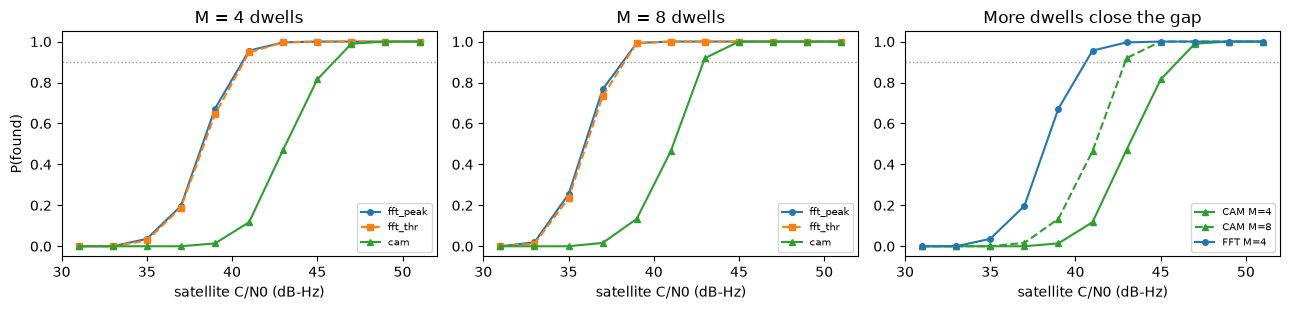

In [21]:
edges  = np.arange(30, 53, 2)
centre = (edges[:-1] + edges[1:]) / 2

def recall_curve(persat):
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        a = np.array([f for c, f in persat if lo <= c < hi])
        out.append(a.mean() if len(a) >= 15 else np.nan)
    return np.array(out)

fig, axes = plt.subplots(1, len(MS)+1, figsize=(13, 3.2))
for ax, m in zip(axes[:len(MS)], MS):
    for n, st in (("fft_peak", "o-"), ("fft_thr", "s--"), ("cam", "^-")):
        ax.plot(centre, recall_curve(PERSAT[m][n]), st, ms=4, label=n)
    ax.axhline(0.9, color="0.6", ls=":", lw=1)
    ax.set(xlabel="satellite C/N0 (dB-Hz)", ylabel="P(found)" if m == MS[0] else "",
           ylim=(-0.05, 1.05), title=f"M = {m} dwells")
    ax.legend(fontsize=7)
ax = axes[-1]
for m, st in zip(MS, ["^-", "^--"]):
    ax.plot(centre, recall_curve(PERSAT[m]["cam"]), st, ms=4, color="C2", label=f"CAM M={m}")
ax.plot(centre, recall_curve(PERSAT[MS[0]]["fft_peak"]), "o-", ms=4, color="C0",
        label=f"FFT M={MS[0]}")
ax.axhline(0.9, color="0.6", ls=":", lw=1)
ax.set(xlabel="satellite C/N0 (dB-Hz)", ylim=(-0.05, 1.05), title="More dwells close the gap")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [22]:
def crossing(persat, target=0.9):
    y = recall_curve(persat)
    for i in range(len(y)-1):
        if np.isfinite(y[i]) and np.isfinite(y[i+1]) and y[i] < target <= y[i+1]:
            return centre[i] + (target-y[i])/(y[i+1]-y[i])*(centre[i+1]-centre[i])
    return np.nan

print("C/N0 for 90% per-satellite recall\n")
print(f"{'detector':>12} " + " ".join(f"{'M=%d'%m:>10}" for m in MS))
for n in ["fft_peak", "fft_thr", "cam"]:
    print(f"{n:>12} " + " ".join(f"{crossing(PERSAT[m][n]):>10.1f}" for m in MS))

gap = crossing(PERSAT[MS[0]]["cam"]) - crossing(PERSAT[MS[0]]["fft_peak"])
print(f"\nCAM - FFT at M={MS[0]}: {gap:+.1f} dB")
print(f"  analytic prediction: 1.96 dB (1-bit front end, nb 02) + 1.9 dB (boolean readout,")
print(f"  nb 08) = {1.96+1.9:.1f} dB against a full-precision FFT.")
print(f"  the earlier hand-written signal model gave +3.4 dB on this same benchmark.")

C/N0 for 90% per-satellite recall

    detector        M=4        M=8
    fft_peak       40.6       38.2
     fft_thr       40.7       38.3
         cam       46.0       42.9

CAM - FFT at M=4: +5.4 dB
  analytic prediction: 1.96 dB (1-bit front end, nb 02) + 1.9 dB (boolean readout,
  nb 08) = 3.9 dB against a full-precision FFT.
  the earlier hand-written signal model gave +3.4 dB on this same benchmark.


---
## 6. What the hand-written model was missing

The signal model this notebook used to carry advanced the carrier correctly but reused the same
code phase for every dwell. Real code Doppler stretches the code as well as the carrier, at
$f_d \cdot f_c / f_{L1} = 6.49\times10^{-4}$ chips/s per Hz, so over an accumulation the peak
**walks**.

Below: gps-sdr-sim's own code phase for one satellite across 8 dwells, against what the old
model would have produced (a flat line), and against the drift rate predicted from the dumped
Doppler.

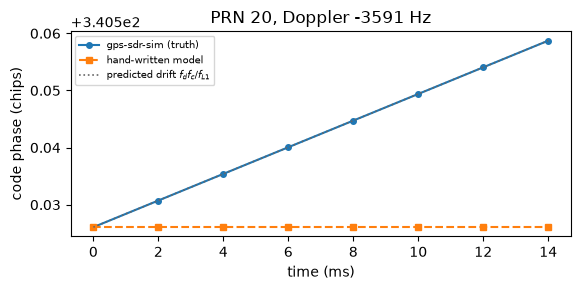

drift over 14 ms : +0.033 chips (measured), +0.033 predicted
a cell is 0.5 chip, so the peak stays put while drift < 0.25 chip
   at   1000 Hz Doppler -> max accumulation  385.0 ms
   at   5000 Hz Doppler -> max accumulation   77.0 ms
   at  10000 Hz Doppler -> max accumulation   38.5 ms


In [23]:
s = SCEN[0]
sat = max(s["truth"][1], key=lambda t: abs(t["fd"]))
n_d = 8
cp_gss, cp_old = [], []
for w in range(n_d):
    dt = w * M_DWELL / FS
    cp_gss.append((CL - (sat["cp_g"] + sat["fcode"]*dt) % CL) % CL)
    cp_old.append((CL - sat["cp_g"]) % CL)             # the old model: never moves
cp_gss = np.unwrap(np.array(cp_gss)/CL*2*np.pi)/(2*np.pi)*CL
t_ms = np.arange(n_d) * M_DWELL / FS * 1e3
pred = cp_gss[0] - sat["fd"] * (1.023e6/L1) * (t_ms/1e3)   # sign: our cp = CL - gps cp

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t_ms, cp_gss, "o-", ms=4, label="gps-sdr-sim (truth)")
ax.plot(t_ms, cp_old, "s--", ms=4, label="hand-written model")
ax.plot(t_ms, pred, ":", lw=1.2, color="0.4", label="predicted drift $f_d f_c/f_{L1}$")
ax.set(xlabel="time (ms)", ylabel="code phase (chips)",
       title=f"PRN {sat['prn']}, Doppler {sat['fd']:+.0f} Hz")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

drift = cp_gss[-1] - cp_gss[0]
print(f"drift over {t_ms[-1]:.0f} ms : {drift:+.3f} chips (measured), "
      f"{pred[-1]-pred[0]:+.3f} predicted")
print(f"a cell is 0.5 chip, so the peak stays put while drift < 0.25 chip")
for fd in (1000, 5000, 10000):
    print(f"   at {fd:>6} Hz Doppler -> max accumulation {0.25/(fd*1.023e6/L1)*1e3:>6.1f} ms")

At $M=8$ the drift is small — a fraction of a cell — so the benchmark above is barely affected,
which the numbers in §5 confirm. But the ceiling it implies matters elsewhere: at 10 kHz Doppler
the peak leaves its cell after **38.5 ms**, and notebook 07 needs 42 ms at $S=6$ and 65 ms at
$S=11$. Those two configurations carry the 8.3x dictionary-reduction claim, and on this evidence
they are not reachable as drawn without accumulating over a cell neighbourhood. Flagged here
against notebooks 07 and 08 rather than silently left; not fixed, because this notebook's scope
is the benchmark.

---
## 7. What this shows

**The result did not survive the change of signal source, and that is the finding.** The
hand-written model put the CAM **3.4 dB** behind a full-precision FFT. Driven by real ephemeris
the gap is **5.4 dB** — two decibels worse. The analytic prediction of 3.9 dB (1.96 dB of 1-bit
quantization from notebook 02, plus 1.9 dB of boolean readout from notebook 08) sits between
them, and it is derived for *one satellite in noise*, which is exactly the situation neither the
real sky nor a real receiver is in.

**The likely cause is near-far, and it is a property of the sky rather than of the detector.**
In the old model every satellite drew its C/N0 independently and uniformly, so a weak satellite
often had no strong companion. Real geometry does not work that way: there is essentially always
a satellite near zenith 10 dB above the one you are struggling with. A hard-limiting front end
is more exposed to that than a full-precision one — 1-bit quantization allocates its single bit
to whatever dominates the sample, and the weak satellite is what gets squeezed. The CAM has a
1-bit front end and the FFT does not, so the penalty lands asymmetrically.

That is a hypothesis consistent with the numbers, not something this notebook measures. Testing
it would mean binning recall by the sky's dynamic range, which needs a re-run; it is the obvious
next experiment and it is not done here.

**Ranking is worth almost nothing.** `fft_peak` and `fft_thr` sit within about 2% of each other
in threshold and within 0.01 in score. The CAM structurally cannot rank; on this evidence that
costs it little. What costs it is quantization and the thresholded readout.

**More dwells close the gap.** The CAM at 8 dwells reaches 42.9 dB-Hz, close to where the FFT
sits at 4. It is not worse at acquisition; it is slower for the same sensitivity, and buys area
and multiplier-free hardware with that time.

**What this still does not test.** Multipath and interference are absent — gps-sdr-sim generates
a clean line-of-sight constellation. Receiver clock error is not modelled, so the ±10 kHz search
range here is pure satellite motion; a real 2 ppm TCXO would add ±3.2 kHz of common-mode offset
and widen the dictionary by roughly a third. Only 20 geometries are sampled and trials within a
scenario share their satellite set, so the effective independent sample count is well below the
trial count.

**The methodological point.** Two bugs in this notebook's history were found by inspection rather
than by test: a hand-written model that never advanced the code phase between dwells, and a
training loop that normalised the FFT surface differently from the detector it was calibrating.
Both produced plausible-looking numbers. The first is gone because the signal is no longer ours
to get wrong; the second was caught only because "more dwells made the FFT worse" is impossible
on its face. Prefer quantities that have a known sign.

---
## 8. Cross-check against the repo

The detectors above were written from scratch in this notebook. They should agree with
`sim/gps`, which is what the rest of the study measures.

In [24]:
import sys
sys.path.insert(0, str(ROOT))
from sim.gps import codebook, quantize
from sim.gps.prn import ca_code_bipolar

cb = codebook.build_codebook(prns=[1, 7, 19], f_max=10e3, t_coh=1e-3, fs=FS, mapping="sign")
mine, _ = build_codebook([1, 7, 19], GRID)
x = np.array([0.3+0.2j, -1.1+0.4j, 0.5-2.0j])
k_repo = quantize.quantize_to_key(x, 1.0, "sign")
mine_key = np.stack([x.real < 0, x.imag < 0], -1).ravel()

print("Gold codes identical  :", all(np.array_equal(ca_code(p), ca_code_bipolar(p)) for p in PRNS))
print("codebook identical    :", np.array_equal(cb.rows, mine))
print("key mapping identical :", np.array_equal(k_repo.astype(bool), mine_key))
print(f"\nnotebook total runtime: {(time.time()-T_ALL)/60:.1f} min")

Gold codes identical  : True
codebook identical    : True
key mapping identical : True

notebook total runtime: 11.2 min
